# 02 — Exploratory Data Analysis and Hypothesis Testing

## Human-to-AI Interaction Shift Analysis

This notebook uses the processed datasets created in `01_data_preparation.ipynb`.

The goal is to analyze whether people are shifting from traditional human-based help-seeking platforms toward AI-based platforms. The analysis focuses on Google Trends patterns, platform traffic context, and external survey evidence.

The notebook includes:

- exploratory analysis of Google Trends data,
- comparison of AI-related and traditional platform trends,
- difference and ratio analysis,
- correlation analysis,
- hypothesis testing,
- platform traffic context analysis,
- Stack Overflow and Pew survey validation.

## 1. Setup and Loading Processed Data

This section imports the required libraries, defines project paths, and loads the processed datasets created in the previous notebook.

**Code purpose:** Import the required libraries and define project folders.

In [369]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_rel

PROJECT_DIR = Path.home() / "Desktop" / "dsa"

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Processed folder exists:", PROCESSED_DIR.exists())
print("Figures folder exists:", FIGURES_DIR.exists())

Processed folder exists: True
Figures folder exists: True


**Code purpose:** Load all processed datasets used in the EDA and hypothesis testing notebook.

In [370]:
google_trends = pd.read_csv(PROCESSED_DIR / "google_trends_cleaned.csv")
traffic_context = pd.read_csv(PROCESSED_DIR / "platform_traffic_context.csv")

stackoverflow_ai_usage = pd.read_csv(PROCESSED_DIR / "stackoverflow_ai_usage_cleaned.csv")
stackoverflow_ai_summary = pd.read_csv(PROCESSED_DIR / "stackoverflow_ai_adoption_valid_summary.csv")

pew_ai_survey = pd.read_csv(PROCESSED_DIR / "pew_ai_survey_cleaned.csv")
pew_ai_heard_summary = pd.read_csv(PROCESSED_DIR / "pew_ai_heard_summary.csv")
pew_ai_attitude_summary = pd.read_csv(PROCESSED_DIR / "pew_ai_attitude_summary.csv")

google_trends["date"] = pd.to_datetime(google_trends["date"], errors="coerce")
traffic_context["month"] = pd.to_datetime(traffic_context["month"], errors="coerce")

print("Google Trends shape:", google_trends.shape)
print("Traffic context shape:", traffic_context.shape)
print("Stack Overflow usage shape:", stackoverflow_ai_usage.shape)
print("Stack Overflow summary shape:", stackoverflow_ai_summary.shape)
print("Pew survey shape:", pew_ai_survey.shape)
print("Pew heard summary shape:", pew_ai_heard_summary.shape)
print("Pew attitude summary shape:", pew_ai_attitude_summary.shape)

Google Trends shape: (1091, 5)
Traffic context shape: (54, 9)
Stack Overflow usage shape: (203812, 6)
Stack Overflow summary shape: (9, 5)
Pew survey shape: (28333, 8)
Pew heard summary shape: (5, 3)
Pew attitude summary shape: (5, 3)


**Code purpose:** Display the first rows of each main dataset to confirm that the processed files were loaded correctly.

In [371]:
print("Google Trends:")
display(google_trends.head())

print("Traffic Context:")
display(traffic_context.head())

print("Stack Overflow AI Adoption Summary:")
display(stackoverflow_ai_summary.head())

print("Pew AI Awareness Summary:")
display(pew_ai_heard_summary.head())

print("Pew AI Attitude Summary:")
display(pew_ai_attitude_summary.head())

Google Trends:


,date,category,keyword,platform_type,trend_score
0,2021-04-01,advice_seeking,Yahoo Answers,forum / Q&A platform,56.0
1,2021-05-01,advice_seeking,Yahoo Answers,forum / Q&A platform,22.0
2,2021-06-01,advice_seeking,Yahoo Answers,forum / Q&A platform,14.0
3,2021-07-01,advice_seeking,Yahoo Answers,forum / Q&A platform,12.0
4,2021-08-01,advice_seeking,Yahoo Answers,forum / Q&A platform,11.0


Traffic Context:


,platform,domain,platform_type,category,month,visits,metric,source,collection_date
0,ChatGPT,chatgpt.com,AI platform,general_help_seeking,2025-10-01,6170000000,visits,WebsiteTrafficChecker,2026-05-03
1,ChatGPT,chatgpt.com,AI platform,general_help_seeking,2025-11-01,5840000000,visits,WebsiteTrafficChecker,2026-05-03
2,ChatGPT,chatgpt.com,AI platform,general_help_seeking,2025-12-01,5520000000,visits,WebsiteTrafficChecker,2026-05-03
3,ChatGPT,chatgpt.com,AI platform,general_help_seeking,2026-01-01,5720000000,visits,WebsiteTrafficChecker,2026-05-03
4,ChatGPT,chatgpt.com,AI platform,general_help_seeking,2026-02-01,5350000000,visits,WebsiteTrafficChecker,2026-05-03


Stack Overflow AI Adoption Summary:


,year,ai_adoption_group,count,valid_responses,percentage
0,2023,does_not_plan_to_use_ai,26221,87973,29.81
1,2023,plans_to_use_ai,22710,87973,25.81
2,2023,uses_ai,39042,87973,44.38
3,2024,does_not_plan_to_use_ai,14837,60907,24.36
4,2024,plans_to_use_ai,8408,60907,13.80


Pew AI Awareness Summary:


,ai_heard,count,percentage
0,1,9407,33.20
1,2,12878,45.45
2,3,5240,18.49
3,8,785,2.77
4,9,23,0.08


Pew AI Attitude Summary:


,ai_cncexc,count,percentage
0,1,4708,16.62
1,2,9252,32.65
2,3,12409,43.80
3,8,1862,6.57
4,9,102,0.36


## 2. Google Trends Overview

This section explores the cleaned Google Trends dataset. The data includes AI-related and traditional help-seeking keywords across advice-seeking, general help-seeking, and study-support categories.

**Code purpose:** Check the available Google Trends categories, keywords, and platform types.

In [372]:
print("Categories:")
print(google_trends["category"].unique())

print("\nKeywords:")
print(google_trends["keyword"].unique())

print("\nPlatform types:")
print(google_trends["platform_type"].unique())

Categories:
['advice_seeking' 'general_help_seeking' 'study_support']

Keywords:
['Yahoo Answers' 'Ask.fm' 'ai friend' 'quora' 'chatgpt help' 'course hero'
 'chatgpt study' 'chegg']

Platform types:
['forum / Q&A platform' 'AI platform' 'study support platform']


**Code purpose:** Count how many observations are available for each keyword and category.

In [373]:
google_trends.groupby(["category", "platform_type", "keyword"]).size()

category              platform_type           keyword      
advice_seeking        AI platform             ai friend         61
                      forum / Q&A platform    Ask.fm            61
                                              Yahoo Answers     61
general_help_seeking  AI platform             chatgpt help      61
                      forum / Q&A platform    quora             61
study_support         AI platform             chatgpt study    262
                      study support platform  chegg            262
                                              course hero      262
dtype: int64

**Code purpose:** Display summary statistics for Google Trends scores by keyword.

In [374]:
google_trends_summary = (
    google_trends
    .groupby(["category", "keyword", "platform_type"])["trend_score"]
    .describe()
    .reset_index()
)

google_trends_summary

,category,keyword,platform_type,count,mean,std,min,25%,50%,75%,max
0,advice_seeking,Ask.fm,forum / Q&A platform,61.0,6.081967,2.491954,3.0,4.00,5.0,7.0,13.0
1,advice_seeking,Yahoo Answers,forum / Q&A platform,61.0,6.508197,7.237916,3.0,4.00,5.0,7.0,56.0
2,advice_seeking,ai friend,AI platform,61.0,20.573770,26.457802,2.0,3.00,12.0,19.0,100.0
3,general_help_seeking,chatgpt help,AI platform,61.0,3.442623,5.439132,0.0,0.00,2.0,3.0,24.0
4,general_help_seeking,quora,forum / Q&A platform,61.0,65.081967,21.185132,25.0,49.00,69.0,81.0,100.0
5,study_support,chatgpt study,AI platform,262.0,7.431298,14.275782,0.0,0.00,3.0,5.0,100.0
6,study_support,chegg,study support platform,262.0,34.629771,17.327706,6.0,20.25,34.0,49.0,71.0
7,study_support,course hero,study support platform,262.0,11.408397,5.573370,3.0,6.00,11.0,15.0,24.0


## 3. Reshaping Google Trends Data for Category-Level Analysis

The cleaned Google Trends dataset is in long format. For comparison plots and hypothesis testing, I reshape each category into a wide format where each keyword becomes a separate column.

**Code purpose:** Create separate wide-format datasets for advice-seeking, general help-seeking, and study-support categories.

In [375]:
advice_df = (
    google_trends[google_trends["category"] == "advice_seeking"]
    .pivot(index="date", columns="keyword", values="trend_score")
    .reset_index()
)

general_df = (
    google_trends[google_trends["category"] == "general_help_seeking"]
    .pivot(index="date", columns="keyword", values="trend_score")
    .reset_index()
)

study_df = (
    google_trends[google_trends["category"] == "study_support"]
    .pivot(index="date", columns="keyword", values="trend_score")
    .reset_index()
)

advice_df.columns.name = None
general_df.columns.name = None
study_df.columns.name = None

print("Advice shape:", advice_df.shape)
print("General help shape:", general_df.shape)
print("Study support shape:", study_df.shape)

display(advice_df.head())
display(general_df.head())
display(study_df.head())

Advice shape: (61, 4)
General help shape: (61, 3)
Study support shape: (262, 4)


,date,Ask.fm,Yahoo Answers,ai friend
0,2021-04-01,13.0,56.0,2.0
1,2021-05-01,12.0,22.0,2.0
2,2021-06-01,12.0,14.0,2.0
3,2021-07-01,11.0,12.0,2.0
4,2021-08-01,11.0,11.0,3.0


,date,chatgpt help,quora
0,2021-04-01,0.0,70.0
1,2021-05-01,0.0,81.0
2,2021-06-01,0.0,80.0
3,2021-07-01,0.0,79.0
4,2021-08-01,0.0,82.0


,date,chatgpt study,chegg,course hero
0,2021-04-11,0.0,71.0,15.0
1,2021-04-18,0.0,66.0,16.0
2,2021-04-25,0.0,66.0,16.0
3,2021-05-02,0.0,61.0,15.0
4,2021-05-09,0.0,56.0,13.0


## 4. Google Trends Visualizations

This section visualizes search interest trends for each category. These plots help identify whether AI-related search terms increase while traditional platforms decline or remain stable.

**Code purpose:** Plot advice-seeking and AI interaction keyword trends over time.

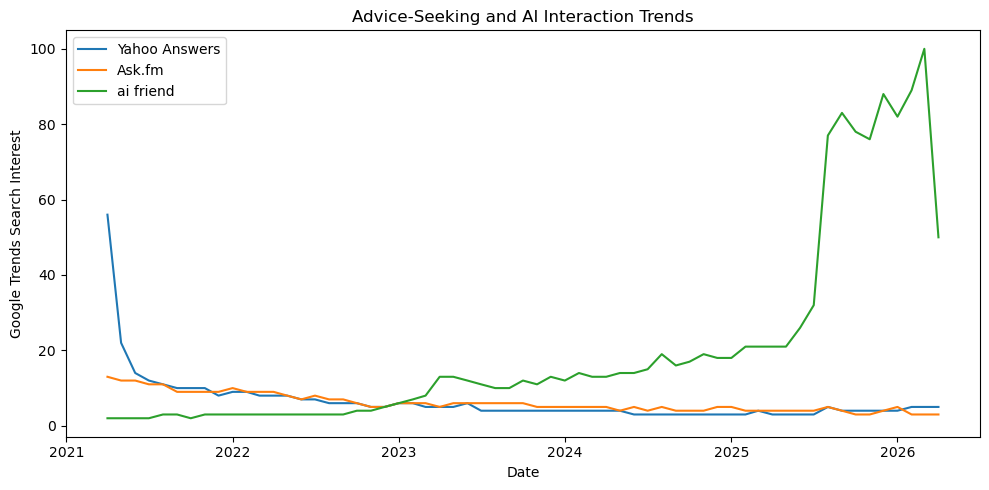

In [376]:
plt.figure(figsize=(10, 5))

for keyword in ["Yahoo Answers", "Ask.fm", "ai friend"]:
    if keyword in advice_df.columns:
        plt.plot(advice_df["date"], advice_df[keyword], label=keyword)

plt.title("Advice-Seeking and AI Interaction Trends")
plt.xlabel("Date")
plt.ylabel("Google Trends Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

**Code purpose:** Plot general help-seeking keyword trends over time.

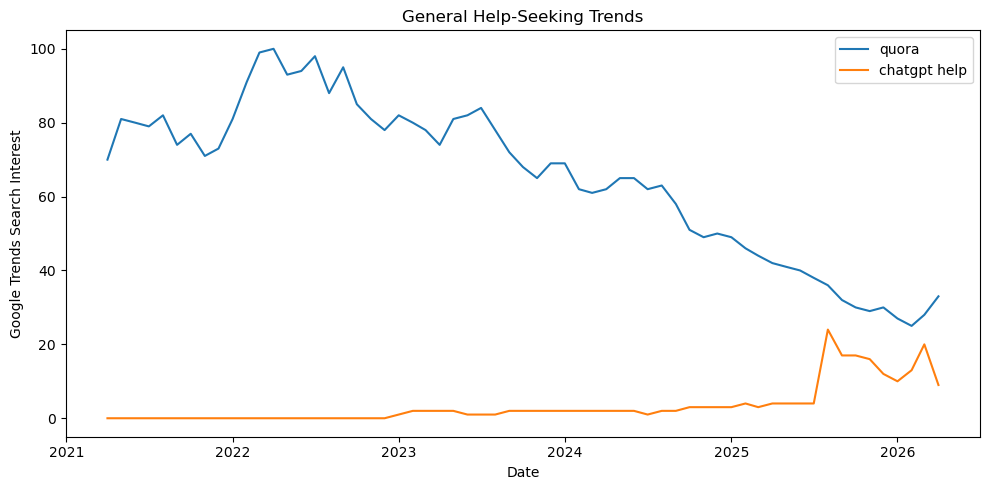

In [377]:
plt.figure(figsize=(10, 5))

for keyword in ["quora", "chatgpt help"]:
    if keyword in general_df.columns:
        plt.plot(general_df["date"], general_df[keyword], label=keyword)

plt.title("General Help-Seeking Trends")
plt.xlabel("Date")
plt.ylabel("Google Trends Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

**Code purpose:** Plot study-support keyword trends over time.

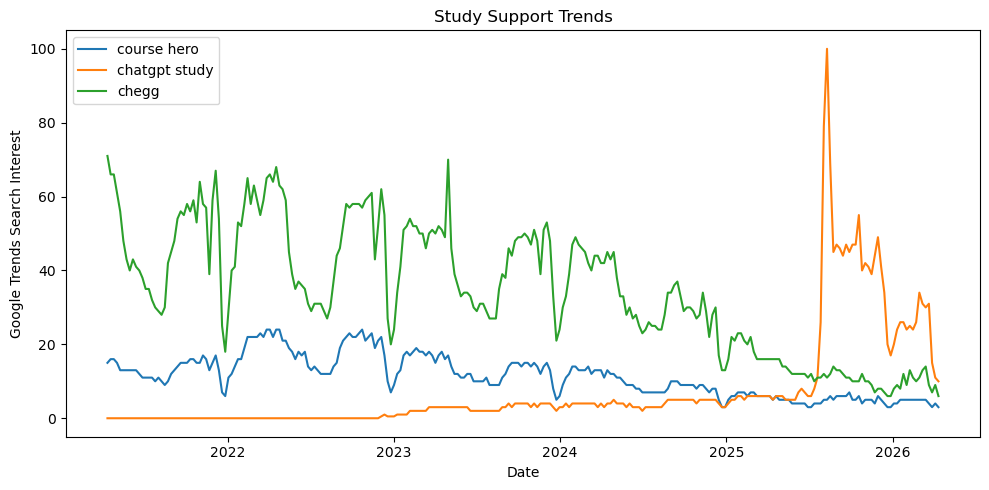

In [378]:
plt.figure(figsize=(10, 5))

for keyword in ["course hero", "chatgpt study", "chegg"]:
    if keyword in study_df.columns:
        plt.plot(study_df["date"], study_df[keyword], label=keyword)

plt.title("Study Support Trends")
plt.xlabel("Date")
plt.ylabel("Google Trends Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

## 5. AI vs Traditional Platform Comparison Metrics

This section creates comparison metrics between AI-related keywords and traditional human-based platforms. I calculate traditional platform averages, differences, and ratios to compare relative search interest.

**Code purpose:** Calculate human/traditional averages, AI-minus-traditional differences, and AI-to-traditional ratios for each category.

In [379]:
advice_df["traditional_avg"] = advice_df[["Yahoo Answers", "Ask.fm"]].mean(axis=1)
advice_df["difference"] = advice_df["ai friend"] - advice_df["traditional_avg"]
advice_df["ratio"] = (advice_df["ai friend"] + 1) / (advice_df["traditional_avg"] + 1)

general_df["traditional_avg"] = general_df["quora"]
general_df["difference"] = general_df["chatgpt help"] - general_df["traditional_avg"]
general_df["ratio"] = (general_df["chatgpt help"] + 1) / (general_df["traditional_avg"] + 1)

study_df["traditional_avg"] = study_df[["course hero", "chegg"]].mean(axis=1)
study_df["difference"] = study_df["chatgpt study"] - study_df["traditional_avg"]
study_df["ratio"] = (study_df["chatgpt study"] + 1) / (study_df["traditional_avg"] + 1)

display(advice_df.head())
display(general_df.head())
display(study_df.head())

,date,Ask.fm,Yahoo Answers,ai friend,traditional_avg,difference,ratio
0,2021-04-01,13.0,56.0,2.0,34.5,-32.5,0.084507
1,2021-05-01,12.0,22.0,2.0,17.0,-15.0,0.166667
2,2021-06-01,12.0,14.0,2.0,13.0,-11.0,0.214286
3,2021-07-01,11.0,12.0,2.0,11.5,-9.5,0.240000
4,2021-08-01,11.0,11.0,3.0,11.0,-8.0,0.333333


,date,chatgpt help,quora,traditional_avg,difference,ratio
0,2021-04-01,0.0,70.0,70.0,-70.0,0.014085
1,2021-05-01,0.0,81.0,81.0,-81.0,0.012195
2,2021-06-01,0.0,80.0,80.0,-80.0,0.012346
3,2021-07-01,0.0,79.0,79.0,-79.0,0.012500
4,2021-08-01,0.0,82.0,82.0,-82.0,0.012048


,date,chatgpt study,chegg,course hero,traditional_avg,difference,ratio
0,2021-04-11,0.0,71.0,15.0,43.0,-43.0,0.022727
1,2021-04-18,0.0,66.0,16.0,41.0,-41.0,0.023810
2,2021-04-25,0.0,66.0,16.0,41.0,-41.0,0.023810
3,2021-05-02,0.0,61.0,15.0,38.0,-38.0,0.025641
4,2021-05-09,0.0,56.0,13.0,34.5,-34.5,0.028169


**Code purpose:** Summarize the comparison metrics for each category.

In [380]:
comparison_summary = pd.DataFrame({
    "category": ["advice_seeking", "general_help_seeking", "study_support"],
    "mean_difference": [
        advice_df["difference"].mean(),
        general_df["difference"].mean(),
        study_df["difference"].mean()
    ],
    "median_difference": [
        advice_df["difference"].median(),
        general_df["difference"].median(),
        study_df["difference"].median()
    ],
    "mean_ratio": [
        advice_df["ratio"].mean(),
        general_df["ratio"].mean(),
        study_df["ratio"].mean()
    ],
    "median_ratio": [
        advice_df["ratio"].median(),
        general_df["ratio"].median(),
        study_df["ratio"].median()
    ]
})

comparison_summary

,category,mean_difference,median_difference,mean_ratio,median_ratio
0,advice_seeking,14.278689,7.5,4.152613,2.181818
1,general_help_seeking,-61.639344,-67.0,0.111655,0.041096
2,study_support,-15.587786,-20.5,0.809824,0.153846


## 6. Difference and Ratio Visualizations

The difference plots show whether AI-related search interest is above or below traditional platform search interest. The ratio plots show the relative strength of AI-related terms compared to traditional platforms.

**Code purpose:** Plot the difference between AI interaction and traditional advice-seeking platforms.

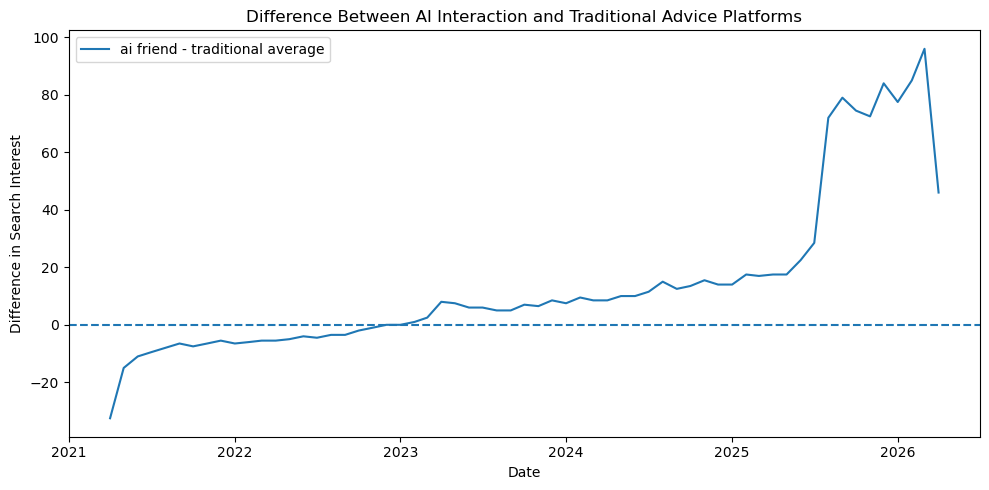

In [381]:
plt.figure(figsize=(10, 5))
plt.plot(advice_df["date"], advice_df["difference"], label="ai friend - traditional average")
plt.axhline(0, linestyle="--")
plt.title("Difference Between AI Interaction and Traditional Advice Platforms")
plt.xlabel("Date")
plt.ylabel("Difference in Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

**Code purpose:** Plot the relative strength of AI interaction compared to traditional advice-seeking platforms.

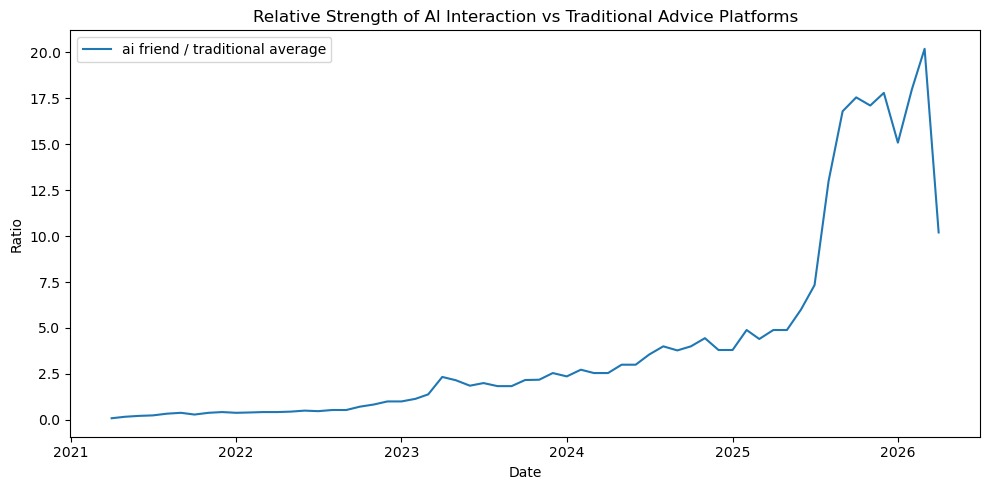

In [382]:
plt.figure(figsize=(10, 5))
plt.plot(advice_df["date"], advice_df["ratio"], label="ai friend / traditional average")
plt.title("Relative Strength of AI Interaction vs Traditional Advice Platforms")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

**Code purpose:** Plot the difference between ChatGPT help and Quora search interest.

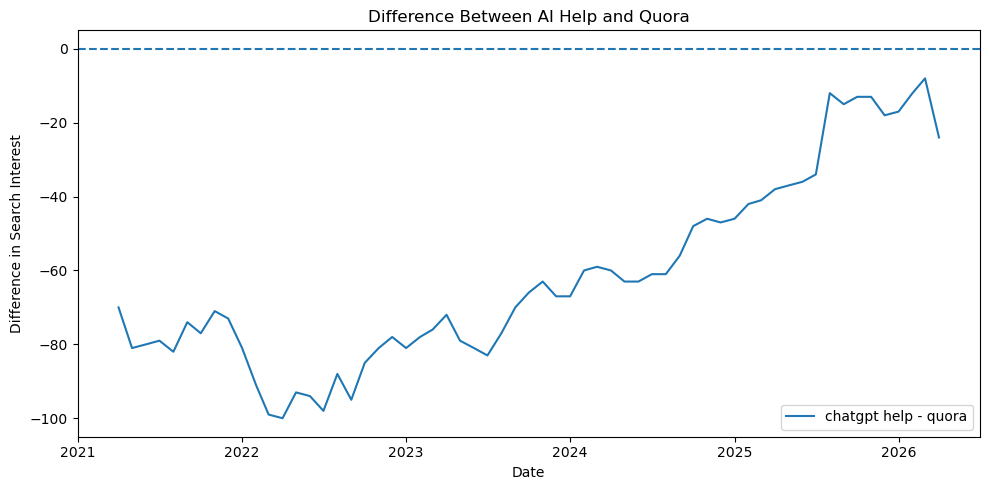

In [383]:
plt.figure(figsize=(10, 5))
plt.plot(general_df["date"], general_df["difference"], label="chatgpt help - quora")
plt.axhline(0, linestyle="--")
plt.title("Difference Between AI Help and Quora")
plt.xlabel("Date")
plt.ylabel("Difference in Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

**Code purpose:** Plot the relative strength of ChatGPT help compared to Quora.

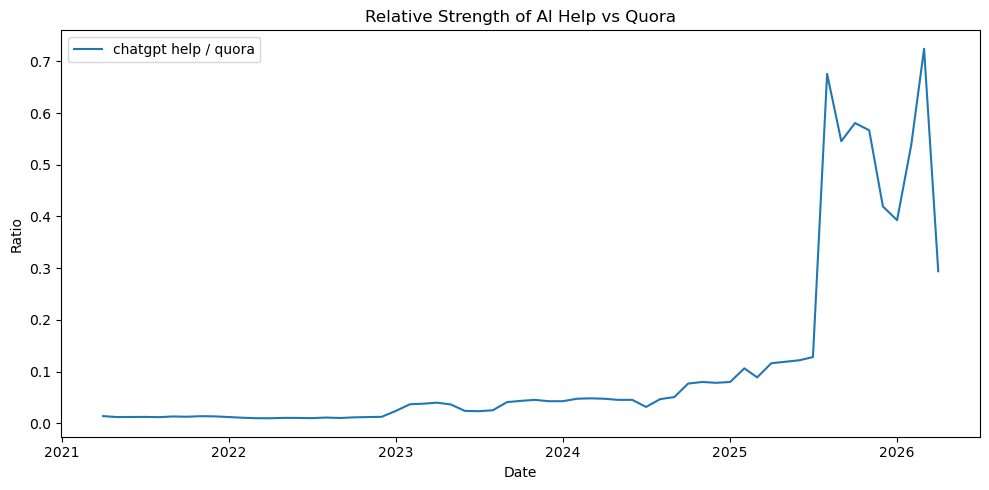

In [384]:
plt.figure(figsize=(10, 5))
plt.plot(general_df["date"], general_df["ratio"], label="chatgpt help / quora")
plt.title("Relative Strength of AI Help vs Quora")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

**Code purpose:** Plot the difference between ChatGPT study and traditional study-support platforms.

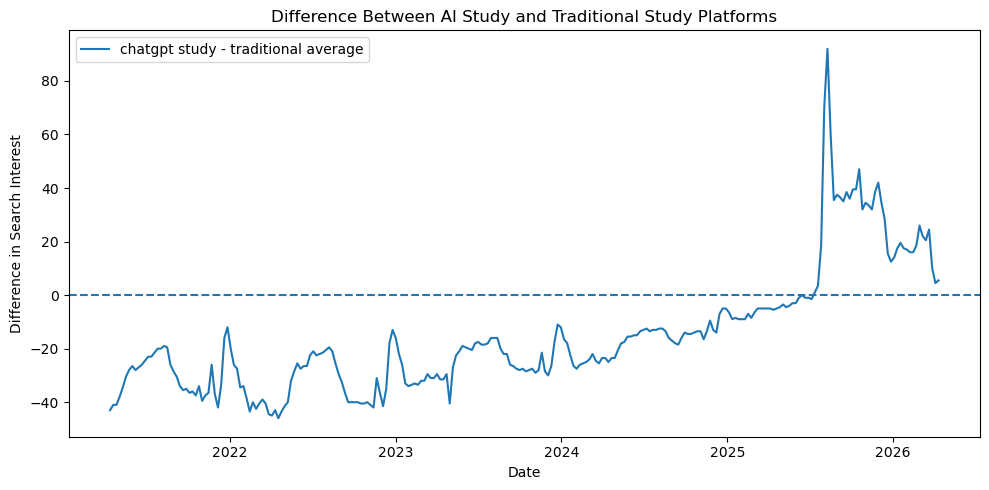

In [385]:
plt.figure(figsize=(10, 5))
plt.plot(study_df["date"], study_df["difference"], label="chatgpt study - traditional average")
plt.axhline(0, linestyle="--")
plt.title("Difference Between AI Study and Traditional Study Platforms")
plt.xlabel("Date")
plt.ylabel("Difference in Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

**Code purpose:** Plot the relative strength of ChatGPT study compared to traditional study-support platforms.

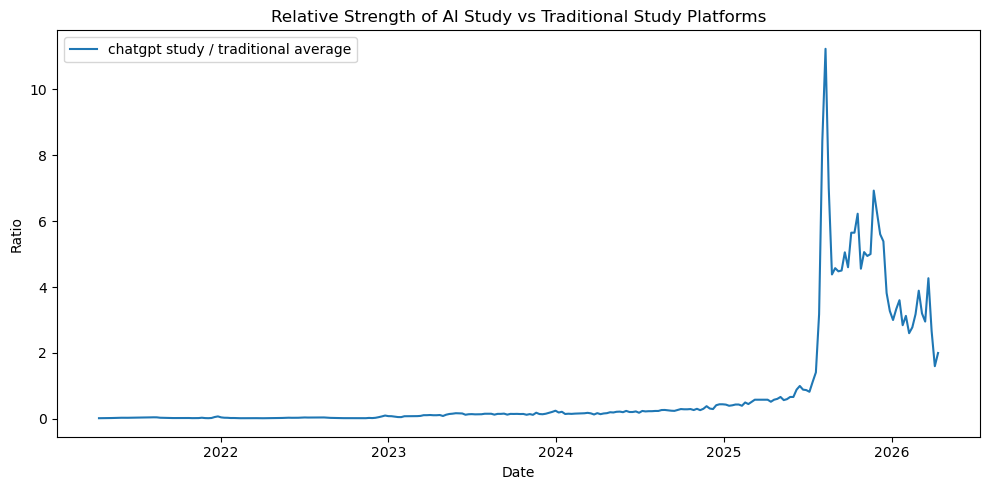

In [386]:
plt.figure(figsize=(10, 5))
plt.plot(study_df["date"], study_df["ratio"], label="chatgpt study / traditional average")
plt.title("Relative Strength of AI Study vs Traditional Study Platforms")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

This section examines the relationship between AI-related and traditional search terms. Negative correlations may suggest that AI-related search interest increases while traditional platform interest decreases.

**Code purpose:** Calculate correlation matrices for each Google Trends category.

In [387]:
print("Advice-seeking correlations:")
display(advice_df[["Yahoo Answers", "Ask.fm", "ai friend", "traditional_avg"]].corr())

print("General help-seeking correlations:")
display(general_df[["quora", "chatgpt help"]].corr())

print("Study-support correlations:")
display(study_df[["course hero", "chatgpt study", "chegg", "traditional_avg"]].corr())

Advice-seeking correlations:


,Yahoo Answers,Ask.fm,ai friend,traditional_avg
Yahoo Answers,1.000000,0.692537,-0.229312,0.980477
Ask.fm,0.692537,1.000000,-0.566210,0.820864
ai friend,-0.229312,-0.566210,1.000000,-0.335884
traditional_avg,0.980477,0.820864,-0.335884,1.000000


General help-seeking correlations:


,quora,chatgpt help
quora,1.000000,-0.772986
chatgpt help,-0.772986,1.000000


Study-support correlations:


,course hero,chatgpt study,chegg,traditional_avg
course hero,1.000000,-0.489455,0.921878,0.954725
chatgpt study,-0.489455,1.000000,-0.568946,-0.557681
chegg,0.921878,-0.568946,1.000000,0.995412
traditional_avg,0.954725,-0.557681,0.995412,1.000000


## 8. Hypothesis Testing

This section uses paired t-tests to examine whether the differences between AI-related and traditional platform search interest are statistically significant.

A paired t-test is used because each AI-related trend value is compared with a traditional platform value from the same time period.

**Code purpose:** Run paired t-tests comparing AI-related search interest with traditional platform search interest.

In [388]:
print("Hypothesis Testing")

print("\n1) ai friend vs traditional advice-seeking average")
print("H0: There is no significant difference between ai friend and the traditional advice-seeking average.")
print("H1: There is a significant difference between ai friend and the traditional advice-seeking average.")
result1 = ttest_rel(advice_df["ai friend"], advice_df["traditional_avg"])
print(result1)

if result1.pvalue < 0.05:
    print("Result: Reject H0. There is a statistically significant difference.")
else:
    print("Result: Fail to reject H0. There is no statistically significant difference.")

print("\n2) chatgpt help vs quora")
print("H0: There is no significant difference between chatgpt help and quora.")
print("H1: There is a significant difference between chatgpt help and quora.")
result2 = ttest_rel(general_df["chatgpt help"], general_df["quora"])
print(result2)

if result2.pvalue < 0.05:
    print("Result: Reject H0. There is a statistically significant difference.")
else:
    print("Result: Fail to reject H0. There is no statistically significant difference.")

print("\n3) chatgpt study vs traditional study-support average")
print("H0: There is no significant difference between chatgpt study and the traditional study-support average.")
print("H1: There is a significant difference between chatgpt study and the traditional study-support average.")
result3 = ttest_rel(study_df["chatgpt study"], study_df["traditional_avg"])
print(result3)

if result3.pvalue < 0.05:
    print("Result: Reject H0. There is a statistically significant difference.")
else:
    print("Result: Fail to reject H0. There is no statistically significant difference.")

Hypothesis Testing

1) ai friend vs traditional advice-seeking average
H0: There is no significant difference between ai friend and the traditional advice-seeking average.
H1: There is a significant difference between ai friend and the traditional advice-seeking average.
TtestResult(statistic=np.float64(3.9375334858463025), pvalue=np.float64(0.00021693998710861778), df=np.int64(60))
Result: Reject H0. There is a statistically significant difference.

2) chatgpt help vs quora
H0: There is no significant difference between chatgpt help and quora.
H1: There is a significant difference between chatgpt help and quora.
TtestResult(statistic=np.float64(-18.78858939685996), pvalue=np.float64(8.121661607895409e-27), df=np.int64(60))
Result: Reject H0. There is a statistically significant difference.

3) chatgpt study vs traditional study-support average
H0: There is no significant difference between chatgpt study and the traditional study-support average.
H1: There is a significant difference b

### Hypothesis Test Interpretation

The hypothesis tests show whether AI-related and traditional search trends differ statistically. A significant result does not automatically prove that users fully shifted from human-based platforms to AI platforms, but it supports the idea that the search patterns are meaningfully different.

## 9. Platform Traffic Context Analysis

This section uses the platform traffic dataset as supporting context. Since the traffic data only covers six months, it is not used as the main evidence for long-term behavioral change. Instead, it helps compare recent platform-level activity across AI, Q&A, general help, and study-support platforms.

**Code purpose:** Summarize average monthly visits by platform and platform type.

In [389]:
traffic_summary = (
    traffic_context
    .groupby(["platform_type", "platform"])["visits"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

traffic_summary

,platform_type,platform,mean,min,max
0,AI platform,Character AI,1.895317e+08,181290000,194620000
1,AI platform,ChatGPT,5.721667e+09,5350000000,6170000000
2,AI platform,Claude,2.255433e+08,172690000,310000000
3,Forum Q&A platform,Quora,3.875183e+08,376250000,397860000
4,General help platform,WikiHow,3.932167e+07,38000000,40590000
5,Study support platform,Chegg,6.878333e+06,4350000,11390000
6,Study support platform,Course Hero,5.858333e+06,4450000,8300000
7,Study support platform,Khan Academy,2.617000e+07,24000000,29800000
8,Study support platform,Quizlet,7.488500e+07,64000000,95160000


**Code purpose:** Plot monthly platform visits using a logarithmic scale so that smaller platforms remain visible.

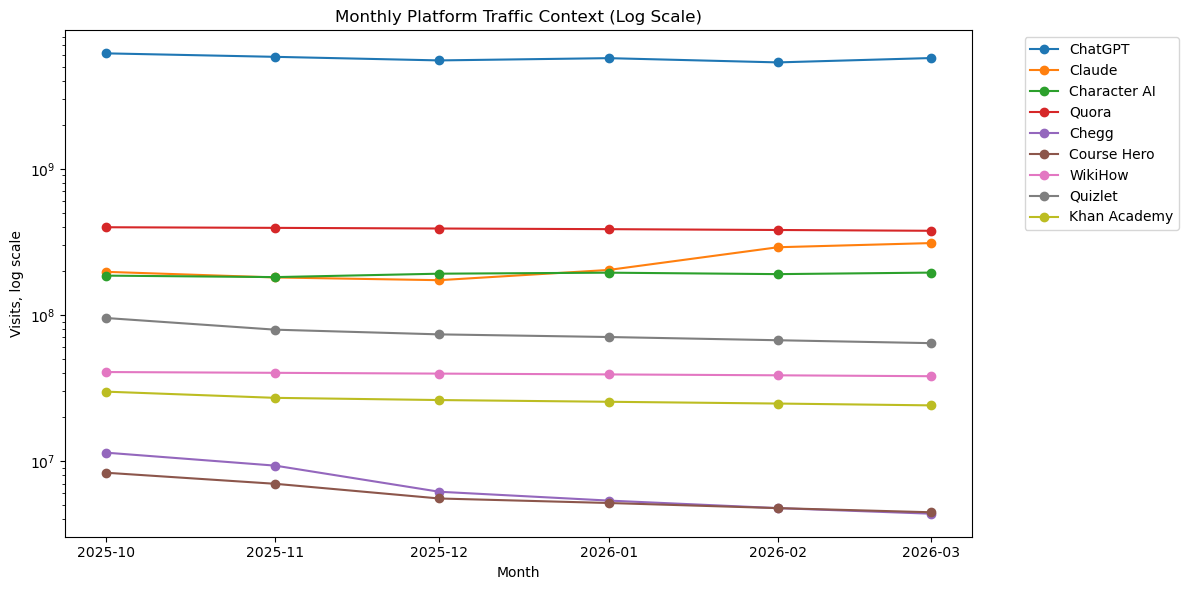

In [390]:
plt.figure(figsize=(12, 6))

for platform in traffic_context["platform"].unique():
    subset = traffic_context[traffic_context["platform"] == platform]
    plt.plot(subset["month"], subset["visits"], marker="o", label=platform)

plt.yscale("log")
plt.title("Monthly Platform Traffic Context (Log Scale)")
plt.xlabel("Month")
plt.ylabel("Visits, log scale")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Code purpose:** Normalize each platform's visits to its first month to compare relative traffic changes over time.

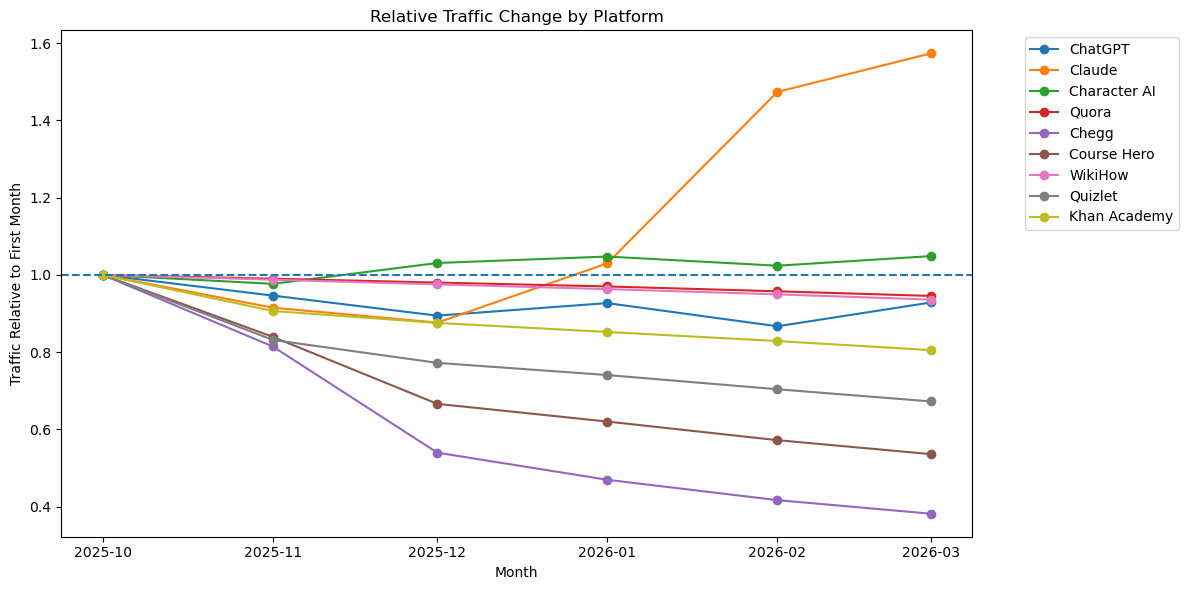

In [391]:
traffic_normalized = traffic_context.copy()

traffic_normalized["normalized_visits"] = (
    traffic_normalized
    .sort_values("month")
    .groupby("platform")["visits"]
    .transform(lambda x: x / x.iloc[0])
)

plt.figure(figsize=(12, 6))

for platform in traffic_normalized["platform"].unique():
    subset = traffic_normalized[traffic_normalized["platform"] == platform]
    plt.plot(subset["month"], subset["normalized_visits"], marker="o", label=platform)

plt.axhline(1, linestyle="--")
plt.title("Relative Traffic Change by Platform")
plt.xlabel("Month")
plt.ylabel("Traffic Relative to First Month")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Code purpose:** Calculate each platform's traffic change from the first month to the last month.

In [392]:
traffic_change_summary = (
    traffic_context
    .sort_values("month")
    .groupby(["platform_type", "platform"])
    .agg(
        first_month=("month", "first"),
        last_month=("month", "last"),
        first_visits=("visits", "first"),
        last_visits=("visits", "last")
    )
    .reset_index()
)

traffic_change_summary["absolute_change"] = (
    traffic_change_summary["last_visits"] - traffic_change_summary["first_visits"]
)

traffic_change_summary["percentage_change"] = (
    traffic_change_summary["absolute_change"] /
    traffic_change_summary["first_visits"] * 100
).round(2)

traffic_change_summary["trend_direction"] = traffic_change_summary["percentage_change"].apply(
    lambda x: "positive" if x > 0 else "negative" if x < 0 else "stable"
)

traffic_change_summary

,platform_type,platform,first_month,last_month,first_visits,last_visits,absolute_change,percentage_change,trend_direction
0,AI platform,Character AI,2025-10-01,2026-03-01,185570000,194620000,9050000,4.88,positive
1,AI platform,ChatGPT,2025-10-01,2026-03-01,6170000000,5730000000,-440000000,-7.13,negative
2,AI platform,Claude,2025-10-01,2026-03-01,197000000,310000000,113000000,57.36,positive
3,Forum Q&A platform,Quora,2025-10-01,2026-03-01,397860000,376250000,-21610000,-5.43,negative
4,General help platform,WikiHow,2025-10-01,2026-03-01,40590000,38000000,-2590000,-6.38,negative
5,Study support platform,Chegg,2025-10-01,2026-03-01,11390000,4350000,-7040000,-61.81,negative
6,Study support platform,Course Hero,2025-10-01,2026-03-01,8300000,4450000,-3850000,-46.39,negative
7,Study support platform,Khan Academy,2025-10-01,2026-03-01,29800000,24000000,-5800000,-19.46,negative
8,Study support platform,Quizlet,2025-10-01,2026-03-01,95160000,64000000,-31160000,-32.74,negative


**Code purpose:** Summarize traffic trend direction by platform type.

In [393]:
traffic_type_change_summary = (
    traffic_change_summary
    .groupby("platform_type")
    .agg(
        average_percentage_change=("percentage_change", "mean"),
        positive_platforms=("trend_direction", lambda x: (x == "positive").sum()),
        negative_platforms=("trend_direction", lambda x: (x == "negative").sum()),
        total_platforms=("platform", "count")
    )
    .reset_index()
)

traffic_type_change_summary["average_percentage_change"] = (
    traffic_type_change_summary["average_percentage_change"].round(2)
)

traffic_type_change_summary

,platform_type,average_percentage_change,positive_platforms,negative_platforms,total_platforms
0,AI platform,18.37,2,1,3
1,Forum Q&A platform,-5.43,0,1,1
2,General help platform,-6.38,0,1,1
3,Study support platform,-40.10,0,4,4


**Code purpose:** Plot average percentage traffic change by platform type.

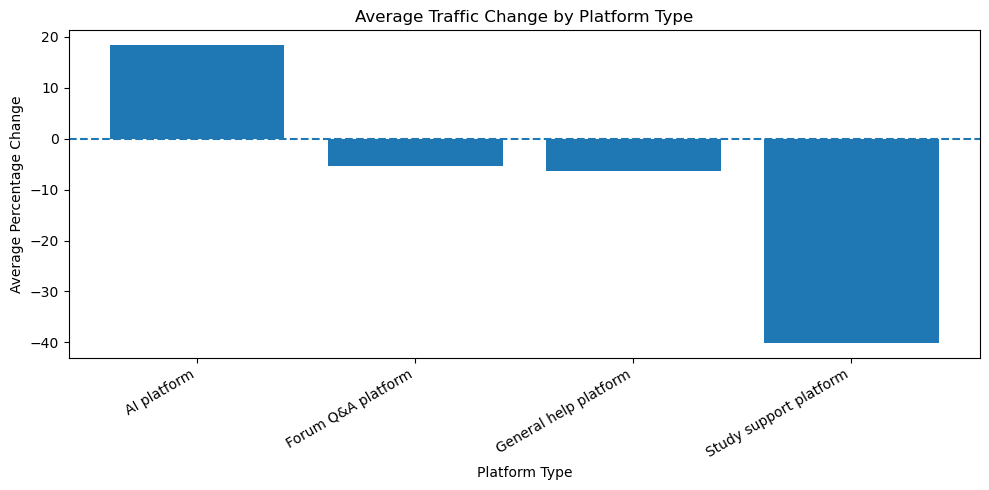

In [394]:
plt.figure(figsize=(10, 5))

plt.bar(
    traffic_type_change_summary["platform_type"],
    traffic_type_change_summary["average_percentage_change"]
)

plt.axhline(0, linestyle="--")
plt.title("Average Traffic Change by Platform Type")
plt.xlabel("Platform Type")
plt.ylabel("Average Percentage Change")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Code purpose:** Plot percentage traffic change for each platform.

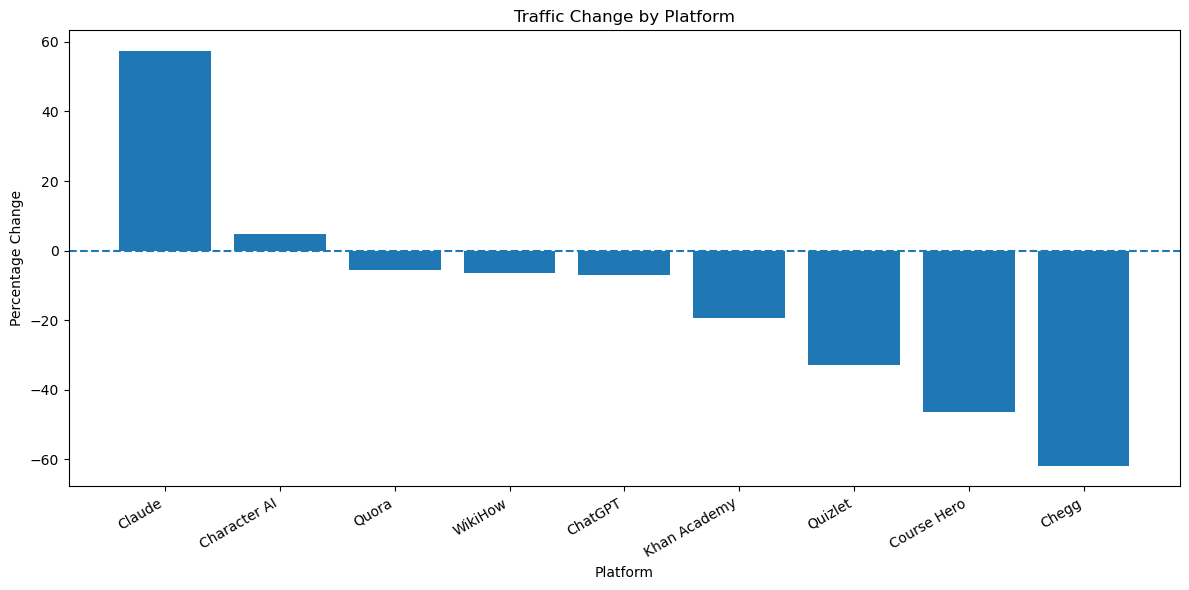

In [395]:
platform_change_sorted = traffic_change_summary.sort_values(
    "percentage_change",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    platform_change_sorted["platform"],
    platform_change_sorted["percentage_change"]
)

plt.axhline(0, linestyle="--")
plt.title("Traffic Change by Platform")
plt.xlabel("Platform")
plt.ylabel("Percentage Change")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Code purpose:** Compare average traffic across platform types.

In [396]:
traffic_type_summary = (
    traffic_context
    .groupby("platform_type")["visits"]
    .mean()
    .reset_index(name="average_monthly_visits")
    .sort_values("average_monthly_visits", ascending=False)
)

traffic_type_summary

,platform_type,average_monthly_visits
0,AI platform,2.045581e+09
1,Forum Q&A platform,3.875183e+08
2,General help platform,3.932167e+07
3,Study support platform,2.844792e+07


**Code purpose:** Plot average monthly visits by platform type using a logarithmic scale.

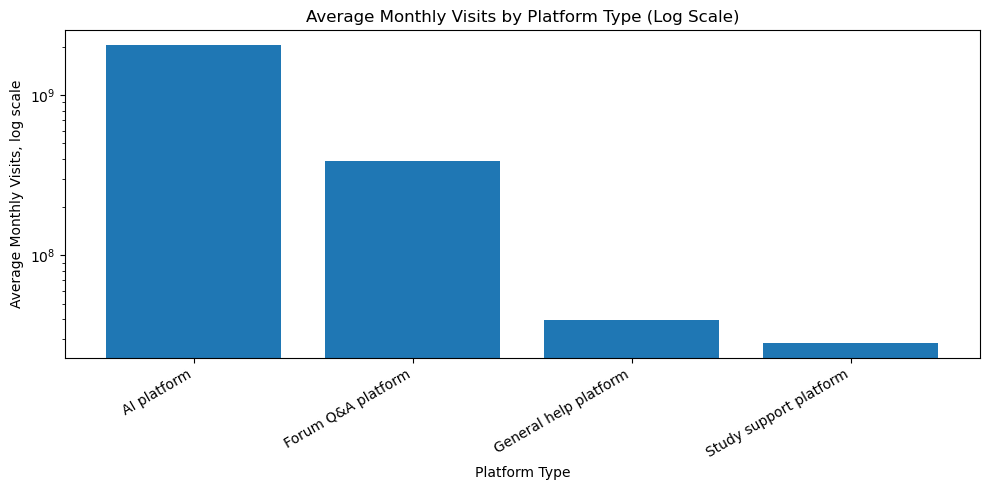

In [397]:
plt.figure(figsize=(10, 5))
plt.bar(
    traffic_type_summary["platform_type"],
    traffic_type_summary["average_monthly_visits"]
)

plt.yscale("log")
plt.title("Average Monthly Visits by Platform Type (Log Scale)")
plt.xlabel("Platform Type")
plt.ylabel("Average Monthly Visits, log scale")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Traffic Change Interpretation

The platform-level traffic results show that some AI platforms, especially Claude and Character AI, increased during the six-month period. ChatGPT shows a slight decrease, but it still has the highest overall traffic volume among all selected platforms.

In contrast, most traditional and study-support platforms show negative percentage change. Quora and WikiHow decline slightly, while Chegg, Course Hero, Quizlet, and Khan Academy show stronger decreases.

Since this dataset only covers six months, it should not be interpreted as proof of a long-term behavioral shift. However, it provides useful recent context that is consistent with the broader pattern observed in the Google Trends analysis.

## 10. Stack Overflow Survey Validation

This section uses Stack Overflow survey summaries as external validation. The survey data helps show whether AI tool adoption increased among Stack Overflow survey respondents.

**Code purpose:** Display the Stack Overflow AI adoption summary used for survey validation.

In [398]:
stackoverflow_ai_summary

,year,ai_adoption_group,count,valid_responses,percentage
0,2023,does_not_plan_to_use_ai,26221,87973,29.81
1,2023,plans_to_use_ai,22710,87973,25.81
2,2023,uses_ai,39042,87973,44.38
3,2024,does_not_plan_to_use_ai,14837,60907,24.36
4,2024,plans_to_use_ai,8408,60907,13.80
5,2024,uses_ai,37662,60907,61.84
6,2025,does_not_plan_to_use_ai,5454,33720,16.17
7,2025,plans_to_use_ai,1797,33720,5.33
8,2025,uses_ai,26469,33720,78.50


**Code purpose:** Reshape the Stack Overflow summary so adoption groups can be compared by year.

In [399]:
stackoverflow_pivot = stackoverflow_ai_summary.pivot(
    index="year",
    columns="ai_adoption_group",
    values="percentage"
).reset_index()

stackoverflow_pivot

ai_adoption_group,year,does_not_plan_to_use_ai,plans_to_use_ai,uses_ai
0,2023,29.81,25.81,44.38
1,2024,24.36,13.80,61.84
2,2025,16.17,5.33,78.50


**Code purpose:** Plot Stack Overflow AI adoption groups by year.

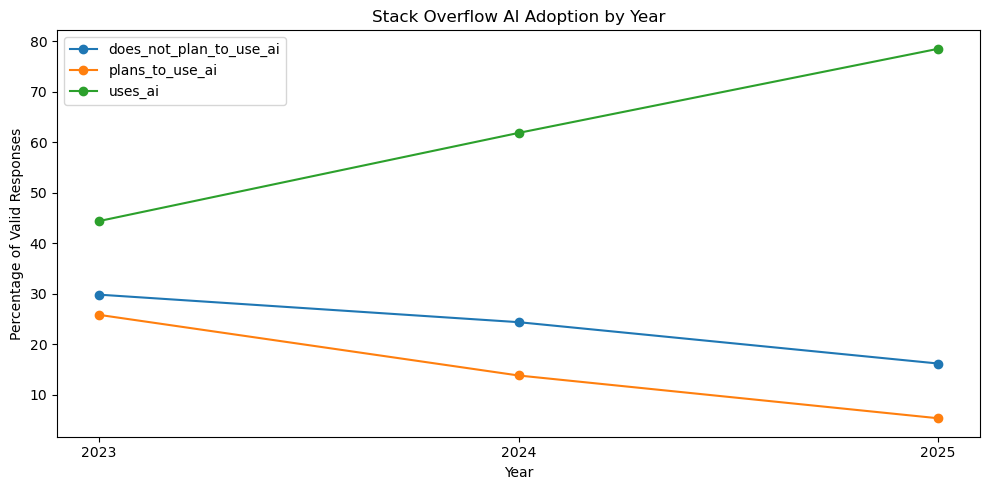

In [400]:
plt.figure(figsize=(10, 5))

for column in stackoverflow_pivot.columns:
    if column != "year":
        plt.plot(
            stackoverflow_pivot["year"],
            stackoverflow_pivot[column],
            marker="o",
            label=column
        )

plt.title("Stack Overflow AI Adoption by Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Valid Responses")
plt.xticks(stackoverflow_pivot["year"])
plt.legend()
plt.tight_layout()
plt.show()

### Stack Overflow Survey Interpretation

The Stack Overflow summary shows that the share of respondents using AI tools increased across the survey years. At the same time, the share of respondents who do not plan to use AI decreased.

The “plans to use AI” group also decreases, but this is not necessarily negative. It can mean that many respondents who previously planned to use AI moved into the active “uses AI” group over time. Therefore, the decline in planning responses can be interpreted together with the strong increase in actual AI usage.

This survey is not used as the main evidence for the project because it represents Stack Overflow survey respondents rather than the entire population. However, it provides useful external validation for the broader pattern observed in the Google Trends analysis.

## 11. Pew AI Survey Validation

This section uses Pew AI survey summaries as broader public context. The Pew data is not used as the main evidence, but it helps describe public awareness of AI and general attitudes toward AI.

**Code purpose:** Display Pew AI awareness and attitude summary tables.

In [401]:
print("Pew AI awareness summary:")
display(pew_ai_heard_summary)

print("Pew AI attitude summary:")
display(pew_ai_attitude_summary)

Pew AI awareness summary:


,ai_heard,count,percentage
0,1,9407,33.20
1,2,12878,45.45
2,3,5240,18.49
3,8,785,2.77
4,9,23,0.08


Pew AI attitude summary:


,ai_cncexc,count,percentage
0,1,4708,16.62
1,2,9252,32.65
2,3,12409,43.80
3,8,1862,6.57
4,9,102,0.36


**Code purpose:** Plot Pew AI awareness response distribution.

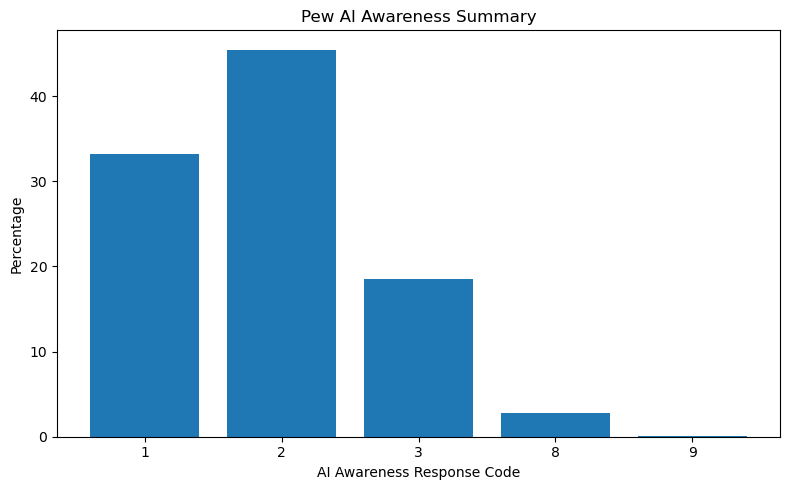

In [402]:
plt.figure(figsize=(8, 5))

plt.bar(
    pew_ai_heard_summary["ai_heard"].astype(str),
    pew_ai_heard_summary["percentage"]
)

plt.title("Pew AI Awareness Summary")
plt.xlabel("AI Awareness Response Code")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

**Code purpose:** Plot Pew AI attitude response distribution.

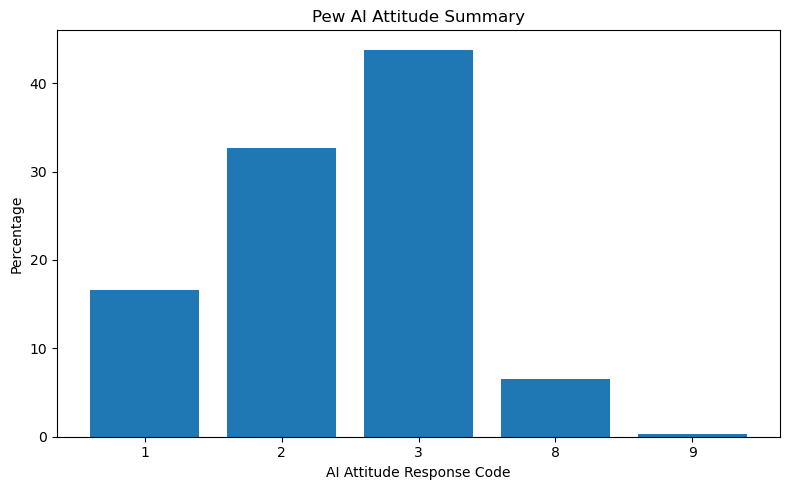

In [403]:
plt.figure(figsize=(8, 5))

plt.bar(
    pew_ai_attitude_summary["ai_cncexc"].astype(str),
    pew_ai_attitude_summary["percentage"]
)

plt.title("Pew AI Attitude Summary")
plt.xlabel("AI Attitude Response Code")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

### Pew Survey Interpretation

The Pew survey is not used to prove a direct shift from traditional help-seeking platforms to AI platforms. Instead, it provides broader external context. The results show that many respondents have at least some awareness of artificial intelligence, which supports the idea that AI has become a socially visible and widely recognized topic.

The attitude results also show that public reactions are mixed and cautious rather than purely positive. This is important because increasing AI visibility does not necessarily mean full public trust or acceptance. For this project, Pew data helps contextualize the Google Trends and Stack Overflow findings by showing that AI adoption and awareness are part of a broader social pattern.

## 12. Overall Evidence Summary

Before writing the final interpretation, I summarize the main findings from each data source. This makes it easier to compare what each dataset contributes to the project.

**Code purpose:** Create a compact summary table showing the role and main finding of each data source.

In [ ]:
overall_evidence_summary = pd.DataFrame({
    "Data source": [
        "Google Trends",
        "Hypothesis tests",
        "Platform traffic",
        "Stack Overflow Survey",
        "Pew AI Survey"
    ],
    "Role in project": [
        "Main behavioral evidence",
        "Statistical support for Google Trends comparisons",
        "Recent platform-level context",
        "External AI adoption validation",
        "Broader public awareness and attitude context"
    ],
    "Main finding": [
        "AI-related search terms show different patterns from traditional help-seeking platforms.",
        "AI-related and traditional search interest differences are statistically significant in selected categories.",
        "Some AI platforms increase while many traditional/study-support platforms decline in the six-month context data.",
        "AI tool usage among respondents increases across survey years.",
        "AI awareness is high, but public attitudes are mixed and cautious."
    ]
})

overall_evidence_summary

**Code purpose:** Create a compact numerical summary of the strongest results used in the interpretation.

In [ ]:
key_numerical_findings = pd.DataFrame({
    "Finding area": [
        "Stack Overflow AI usage",
        "Stack Overflow AI usage",
        "Stack Overflow AI usage",
        "Pew AI awareness",
        "Pew AI attitude",
        "Traffic context"
    ],
    "Measure": [
        "Uses AI, valid responses",
        "Uses AI, valid responses",
        "Uses AI, valid responses",
        "Heard at least something about AI",
        "Largest attitude group",
        "Traffic change direction"
    ],
    "Result": [
        "44.38% in 2023",
        "61.84% in 2024",
        "78.50% in 2025",
        "About 78.65%",
        "More concerned / cautious group is largest",
        "Claude and Character AI increase; many traditional platforms decline"
    ]
})

key_numerical_findings

## 13. Overall Interpretation and Conclusion

**Code purpose:** Summarize the hypothesis test results in a readable table.

In [ ]:
hypothesis_results_summary = pd.DataFrame({
    "Comparison": [
        "ai friend vs traditional advice average",
        "chatgpt help vs quora",
        "chatgpt study vs traditional study average"
    ],
    "Test": [
        "Paired t-test",
        "Paired t-test",
        "Paired t-test"
    ],
    "t-statistic": [
        round(result1.statistic, 4),
        round(result2.statistic, 4),
        round(result3.statistic, 4)
    ],
    "p-value": [
        result1.pvalue,
        result2.pvalue,
        result3.pvalue
    ],
    "Decision": [
        "Reject H0" if result1.pvalue < 0.05 else "Fail to reject H0",
        "Reject H0" if result2.pvalue < 0.05 else "Fail to reject H0",
        "Reject H0" if result3.pvalue < 0.05 else "Fail to reject H0"
    ]
})

hypothesis_results_summary

In [ ]:
## 13. Overall Interpretation and Conclusion

This project combines Google Trends, platform traffic data, Stack Overflow survey results, and Pew AI survey results to examine whether AI-based platforms are becoming more important in help-seeking, advice-seeking, and study-support contexts.

### Main Findings

- **Google Trends is the main evidence.** AI-related search terms such as `ai friend`, `chatgpt help`, and `chatgpt study` show different patterns from traditional platforms such as Yahoo Answers, Ask.fm, Quora, Chegg, and Course Hero.

- **Difference and ratio analyses support this pattern.** These metrics show how AI-related search interest compares with traditional platform interest within the same category and time period.

- **Hypothesis tests show statistically significant differences.** The paired t-tests suggest that AI-related and traditional search interest patterns are meaningfully different. However, this does not prove that individual users directly replaced traditional platforms with AI platforms.

- **Traffic data provides recent context.** Some AI platforms, especially Claude and Character AI, show positive traffic change, while many traditional and study-support platforms show negative change. Since this data only covers six months, it is used as supporting context rather than main evidence.

- **Survey data provides external validation.** Stack Overflow shows increasing AI tool usage among respondents, while Pew shows that AI awareness is high but public attitudes are mixed and cautious.

### Final Conclusion

Overall, the results support the idea that AI platforms are becoming increasingly important in online help-seeking and study-support behavior. The strongest support comes from Google Trends and hypothesis testing, while traffic and survey data strengthen the interpretation with additional context.

The findings suggest a shift in attention and search behavior toward AI-based tools, but they should not be interpreted as complete replacement of traditional human-based platforms.